In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
df = pd.read_csv("./EqRAM/Data/Pulse_train/005/pulse_train.csv", sep=",")

## 1. Linearity and Symmetry

Linearity - Every pulse should change the conductance by the same small amount.  
Symmetry - Is conductance change by +V the same as conductance change by -V.

In [3]:
# Last cycle only - after device has stabilized
df_last = df.tail(400).reset_index(drop=True)

In [15]:
from matplotlib.pyplot import plot


def linfit(df, plot=False):
    df["G"] = df["Id (A)"] / df["Vd (V)"]
    df["ΔG"] = df["G"].diff()
    df["pulse_idx"] = np.arange(1, len(df)+1)

    dfp = df.dropna(subset=["ΔG"]).copy()

    x = dfp["pulse_idx"]
    y = dfp["ΔG"]

    coeffs = np.polyfit(x, y, 2)
    poly = np.poly1d(coeffs)
    yfit = poly(x)

    residuals = y - yfit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot

    if plot == True:
        plt.figure(figsize=(6,4))
        plt.scatter(x, y, color="green", label="Measured ΔG")
        plt.plot(x, yfit, "k--", label=f"Quadratic fit (R²={r2:.3f})")
        plt.xlabel("Pulse")
        plt.ylabel("ΔG")
        plt.title("Linearity")
        plt.grid(True, ls='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    a, b, c = coeffs
    print(f"Polynomial fit: ΔG = {a:.3e}x² + {b:.3e}x + {c:.3e}")
    print(f"R² = {r2:.4f}")


Positive Pulses:


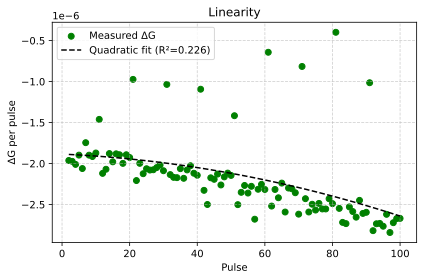

Polynomial fit: ΔG = -5.748e-11x² + -1.807e-09x + -1.885e-06
R² = 0.2261


Negative Pulses:


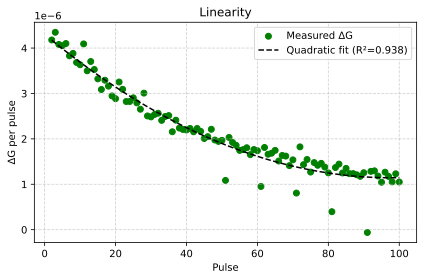

Polynomial fit: ΔG = 3.299e-10x² + -6.455e-08x + 4.302e-06
R² = 0.9384


In [ ]:
df_pos = df_last[df_last["Vg (V)"] > 0].copy()
df_neg = df_last[df_last["Vg (V)"] < 0].copy()

print("Positive Pulses:")
linfit(df_pos, plot=True)

print("\n\nNegative Pulses:")
linfit(df_neg, plot=True)


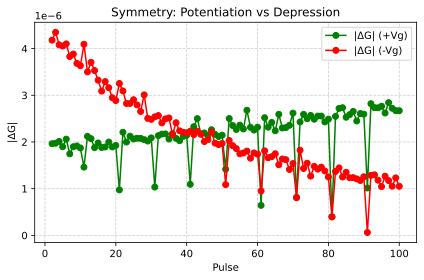

In [10]:
plt.figure(figsize=(6,4))
plt.plot(df_pos["pulse_idx"], abs(df_pos["ΔG"]), 'o-', color='green', label='|ΔG| (+Vg)')
plt.plot(df_neg["pulse_idx"], abs(df_neg["ΔG"]), 'o-', color='red', label='|ΔG| (-Vg)')
plt.xlabel("Pulse")
plt.ylabel("|ΔG|")
plt.title("Symmetry: Potentiation vs Depression")
plt.legend()
plt.grid(True, ls='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 2. Stability

In [19]:
df5 = df.iloc[5::10].reset_index(drop=True)
rows_per_cycle = 40  # 20 positive + 20 negative blocks if 10Vpos + 10Vneg per cycle
n_cycles = len(df5) // rows_per_cycle

df5["cycle"] = np.repeat(np.arange(1, n_cycles+1), rows_per_cycle)

# compute conductance and ΔG for each cycle
df5["G"] = df5["Id (A)"] / df5["Vd (V)"]
df5["ΔG"] = df5.groupby("cycle")["G"].diff()

In [13]:
cycle_stats = df5.groupby(["cycle", "Vg (V)"]).agg({"ΔG":"mean"}).reset_index()

# separate pos/neg
pos_stats = cycle_stats[cycle_stats["Vg (V)"] > 0]
neg_stats = cycle_stats[cycle_stats["Vg (V)"] < 0]


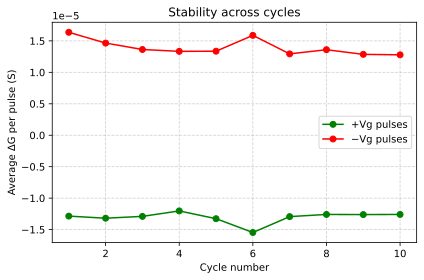

In [14]:
plt.figure(figsize=(6,4))
plt.plot(pos_stats["cycle"], pos_stats["ΔG"], "o-", color="green", label="+Vg pulses")
plt.plot(neg_stats["cycle"], neg_stats["ΔG"], "o-", color="red", label="−Vg pulses")
plt.xlabel("Cycle number")
plt.ylabel("Average ΔG per pulse (S)")
plt.title("Stability across cycles")
plt.grid(True, ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


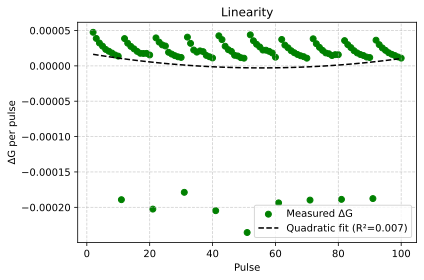

Polynomial fit: ΔG = 6.705e-09x² + -7.444e-07x + 1.776e-05
R² = 0.0066


In [ ]:
df5 = df.iloc[5::10].reset_index(drop=True)
df_reduced = df5.dropna(subset=["ΔG"]).copy()
linfit(df_reduced[df_reduced["Vg (V)"] < 0].copy())

In [20]:
for cyc in df5["cycle"].unique():
    df_c = df5[df5["cycle"] == cyc]
    df_c = df_c.dropna(subset=["ΔG"])
    coeffs = np.polyfit(df_c.index, df_c["ΔG"], 2)
    a,b,c = coeffs
    r2 = 1 - np.sum((df_c["ΔG"] - np.polyval(coeffs, df_c.index))**2) / np.sum((df_c["ΔG"] - np.mean(df_c["ΔG"]))**2)
    print(f"Cycle {cyc}: a={a:.2e}, R²={r2:.3f}")


Cycle 1: a=-2.53e-08, R²=0.488
Cycle 2: a=-1.43e-08, R²=0.477
Cycle 3: a=-2.17e-08, R²=0.514
Cycle 4: a=-1.96e-08, R²=0.502
Cycle 5: a=-1.97e-08, R²=0.449
Cycle 6: a=-2.40e-08, R²=0.545
Cycle 7: a=-2.23e-08, R²=0.535
Cycle 8: a=-1.59e-08, R²=0.511
Cycle 9: a=-1.80e-08, R²=0.512
Cycle 10: a=-1.74e-08, R²=0.496


## Experiment 1

V = 0.3, 0.5, 0.7, 0.9   
   
No. of pulses = 20   
No. of cycles = 3   
Pulse width and delay = 0.5 s   

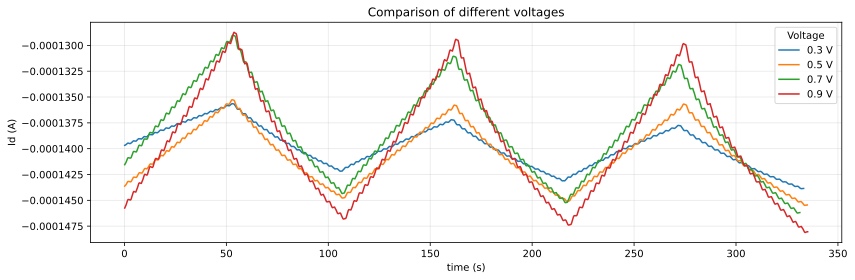

In [10]:
base = Path("./EqRAM/Data/Pulse_train")
folders = {"008": "0.3 V", "009": "0.5 V", "010": "0.7 V", "011": "0.9 V"}

plt.figure(figsize=(12, 4))
for f, label in folders.items():
    csv_path = base / f / "pulse_train.csv"
    df = pd.read_csv(csv_path)
    plt.plot(df["time (s)"], df["Id (A)"], label=label, linewidth=1.5)

plt.xlabel("time (s)")
plt.ylabel("Id (A)")
plt.title("Comparison of different voltages")
plt.legend(title="Voltage")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
for f, label in folders.items():
    df = pd.read_csv(base / f / "pulse_train.csv")
    df_last = df.iloc[800:1200].reset_index(drop=True)

    df_pos = df_last[df_last["Vg (V)"] > 0].copy()
    df_neg = df_last[df_last["Vg (V)"] < 0].copy()

    print(f"\n\nResults for voltage {label}:")
    
    print("Positive Pulses:")
    linfit(df_pos)

    print("\n\nNegative Pulses:")
    linfit(df_neg)




Results for voltage 0.3 V:
Positive Pulses:
Polynomial fit: ΔG = -1.176e-11x² + 2.082e-09x + -5.976e-07
R² = 0.0349


Negative Pulses:
Polynomial fit: ΔG = 2.642e-11x² + -6.979e-09x + 8.690e-07
R² = 0.5439


Results for voltage 0.5 V:
Positive Pulses:
Polynomial fit: ΔG = -5.755e-11x² + 5.326e-09x + -1.009e-06
R² = 0.0424


Negative Pulses:
Polynomial fit: ΔG = 7.663e-11x² + -1.599e-08x + 1.527e-06
R² = 0.6570


Results for voltage 0.7 V:
Positive Pulses:
Polynomial fit: ΔG = 9.624e-12x² + -1.120e-09x + -1.300e-06
R² = 0.0008


Negative Pulses:
Polynomial fit: ΔG = 1.166e-10x² + -2.543e-08x + 2.314e-06
R² = 0.8258


Results for voltage 0.9 V:
Positive Pulses:
Polynomial fit: ΔG = -6.453e-11x² + 1.188e-09x + -1.590e-06
R² = 0.2105


Negative Pulses:
Polynomial fit: ΔG = 2.101e-10x² + -4.309e-08x + 3.287e-06
R² = 0.8995


## Experiment 2
   
V = 0.7 V   
   
No. of pulses = 20, 30, 50    

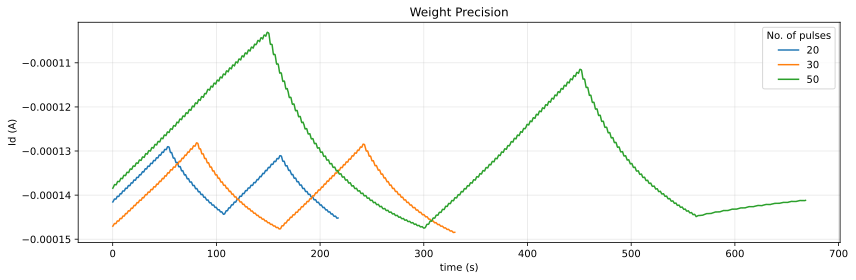

In [11]:
folders = {"010": 20, "012": 30, "013": 50}
row_limit = {"010": 800, "012": 1200, "013": 2000}

plt.figure(figsize=(12, 4))
for f, label in folders.items():
    csv_path = base / f / "pulse_train.csv"
    df = pd.read_csv(csv_path)

    n = row_limit.get(f, len(df))
    df = df.iloc[:min(n, len(df))]
    
    plt.plot(df["time (s)"], df["Id (A)"], label=label, linewidth=1.5)

plt.xlabel("time (s)")
plt.ylabel("Id (A)")
plt.title("Weight Precision")
plt.legend(title="No. of pulses")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Experiment 3

In [5]:
def analyze_pulse_train(csv_file, voltage_col="Vg (V)", current_col="Id (A)", pulse_voltage=0.7):
    df = pd.read_csv(csv_file)
    t = df["time (s)"].to_numpy(dtype=float)
    Vg = df[voltage_col].to_numpy(dtype=float)
    Id = df[current_col].to_numpy(dtype=float)

    # detect pulse regions
    mask = Vg > pulse_voltage / 2

    segments = []
    start = None
    for i, m in enumerate(mask):
        if m and start is None:
            start = i
        elif not m and start is not None:
            segments.append((start, i - 1))
            start = None
    if start is not None:
        segments.append((start, len(mask) - 1))

    rows = []
    for k, (s, e) in enumerate(segments[:-1], start=1):
        if s == 0:
            continue  # first pulse has no previous baseline

        initial_level = Id[s - 1]                  # just before current pulse
        after_pulse = Id[e + 1]                    # first point after pulse
        drifted_next_level = Id[segments[k][0] - 1]  # just before next pulse

        drift_value = drifted_next_level - after_pulse
        drifted_next_minus_initial = drifted_next_level - initial_level

        rows.append({
            "pulse": k,
            "initial_level": initial_level,
            "after_pulse": after_pulse,
            "drifted_next_level": drifted_next_level,
            "drift_value": drift_value,
            "drifted_next_minus_initial": drifted_next_minus_initial
        })

    result = pd.DataFrame(rows)

    print("\nPer-pulse values:\n")
    print(result.to_string(index=False))

    print("\nAverages:\n")
    print("Average drift value =", result["drift_value"].mean())
    print("Average drifted next - initial level =", result["drifted_next_minus_initial"].mean())

    return result

# Example:
res1 = analyze_pulse_train('C:\\Users\\rames\\OneDrive - TU Eindhoven\\Thesis\\Code\\Data\\V0_architecture\\031\\pulse_train1.csv')

res2 = analyze_pulse_train('C:\\Users\\rames\\OneDrive - TU Eindhoven\\Thesis\\Code\\Data\\V0_architecture\\033\\pulse_train1.csv')


Per-pulse values:

 pulse  initial_level  after_pulse  drifted_next_level   drift_value  drifted_next_minus_initial
     2      -0.000057    -0.000045           -0.000052 -7.185450e-06                4.597560e-06
     3      -0.000052    -0.000039           -0.000047 -8.532640e-06                5.062900e-06
     4      -0.000047    -0.000034           -0.000042 -8.227800e-06                5.416040e-06
     5      -0.000042    -0.000034           -0.000039 -5.413920e-06                2.932040e-06
     6      -0.000039    -0.000038           -0.000040 -1.764030e-06               -1.218090e-06
     7      -0.000040    -0.000039           -0.000041 -1.347030e-06               -3.379400e-07
     8      -0.000041    -0.000040           -0.000041 -1.163630e-06               -2.318900e-07
     9      -0.000041    -0.000040           -0.000041 -9.749300e-07               -1.894500e-07

Averages:

Average drift value = -4.326178749999997e-06
Average drifted next - initial level = 2.00389625e

# Experiment 4

NOTE: These cells run only along with the pulse train script

In [ ]:
import pandas as pd
import time

In [ ]:
def measure_read_noise(
    smu, uzi, device_ids, drain='smua', gate='smub',
    read_voltage=-0.1, measPeriod=0.1, n_reads=100
):

    results = {}

    t0 = time.time()

    try:
        for d in device_ids.keys():
            r, w = device_ids.get(d)

            print(f"\nMeasuring read noise for device {d}...")

            t_all, Vg_all, Id_all, Ig_all, Vd_all, G_all = [], [], [], [], [], []

            ON(r)
            OFF(w)

            smu.apply_voltage(gate, read_voltage)

            for k in range(n_reads):
                time.sleep(measPeriod)
                ts_m = time.time() - t0

                iA, iB, vA = smu.measure_all(drain, gate)   # Id, Ig, Vd
                vG = read_voltage
                G = iA / vA if abs(vA) > 1e-12 else np.nan

                t_all.append(ts_m)
                Vg_all.append(vG)
                Id_all.append(iA)
                Ig_all.append(iB)
                Vd_all.append(vA)
                G_all.append(G)

            OFF(r)
            smu.apply_voltage(gate, 0.0)

            G_arr = np.array(G_all, dtype=float)
            Id_arr = np.array(Id_all, dtype=float)

            results[d] = {
                "t": np.array(t_all),
                "Vg": np.array(Vg_all),
                "Id": Id_arr,
                "Ig": np.array(Ig_all),
                "Vd": np.array(Vd_all),
                "G": G_arr,
                "Id_mean": np.nanmean(Id_arr),
                "Id_std": np.nanstd(Id_arr, ddof=1),
                "G_mean": np.nanmean(G_arr),
                "G_std": np.nanstd(G_arr, ddof=1),
            }

            print(f"Device {d}:")
            print(f"  Id mean = {results[d]['Id_mean']:.6e} A")
            print(f"  Id std  = {results[d]['Id_std']:.6e} A")
            print(f"  G mean  = {results[d]['G_mean']:.6e} S")
            print(f"  G std   = {results[d]['G_std']:.6e} S")

    finally:
        smu.close()
        plt.ioff()
        print("\nRead noise measurement complete.")

    return results

In [ ]:
read_results = measure_read_noise(
    smu=smu,
    uzi=uzi,
    device_ids=device_ids,
    drain='smua',
    gate='smub',
    read_voltage=-0.1,
    measPeriod=0.1,
    n_reads=100
)

def save_read_noise_results(results, folder="read_noise_results"):
    os.makedirs(folder, exist_ok=True)

    summary_rows = []

    for d, res in results.items():
        df = pd.DataFrame({
            "t (s)": res["t"],
            "Vg (V)": res["Vg"],
            "Id (A)": res["Id"],
            "Ig (A)": res["Ig"],
            "Vd (V)": res["Vd"],
            "G (S)": res["G"],
        })

        df.to_csv(f"{folder}/device_{d}_read_noise.csv", index=False)

        summary_rows.append({
            "Device": d,
            "Id_mean (A)": res["Id_mean"],
            "Id_std (A)": res["Id_std"],
            "G_mean (S)": res["G_mean"],
            "G_std (S)": res["G_std"],
        })

    pd.DataFrame(summary_rows).to_csv(f"{folder}/read_noise_summary.csv", index=False)
    print(f"Saved read-noise data in: {folder}")

In [ ]:

file_path = "read_noise_results/device_1_read_noise.csv"   
df = pd.read_csv(file_path)

G_col = "G (S)"   

G = df[G_col].to_numpy()
x = np.arange(len(G))

# degree=1 means straight-line trend
coeffs = np.polyfit(x, G, 2)
G_trend = np.polyval(coeffs, x)
G_noise = G - G_trend

sigma_read = np.std(G_noise, ddof=1)

print(f"Read noise after detrending = {sigma_read:.6e} S")

# original G and trend 
plt.figure(figsize=(7,4))
plt.plot(x + 1, G, 'o-', label='Measured G')
plt.plot(x + 1, G_trend, '--', label='Trend')
plt.xlabel("Read number")
plt.ylabel("G (S)")
plt.title("Conductance with fitted trend")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# detrended noise 
plt.figure(figsize=(7,4))
plt.plot(x + 1, G_noise, 'o-')
plt.xlabel("Read number")
plt.ylabel("G_noise (S)")
plt.title(f"Detrended read noise\nstd = {sigma_read:.3e} S")
plt.grid(True)
plt.tight_layout()
plt.show()

# histogram 
plt.figure(figsize=(7,4))
plt.hist(G_noise, bins=15, edgecolor='black')
plt.xlabel("G_noise (S)")
plt.ylabel("Count")
plt.title(f"Read noise distribution\nstd = {sigma_read:.3e} S")
plt.grid(True)
plt.tight_layout()
plt.show()